# Flight Price Prediction — Exploratory Data Analysis

Regression on an Indian airline ticket price dataset (~300k rows; subsampled to 50,000 for tractable training). Target: `price` in INR. Features include airline, source / destination city, departure / arrival time bucket, number of stops, travel class (Economy / Business), flight duration in hours, and days-until-departure.

**Target:** `price` (continuous)

## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
df = pd.read_csv('data/flights.csv')
from utils import load_data
df = load_data()  # subsamples to 50k rows
print('After subsample:', df.shape)
print('Shape:', df.shape)
df.head()

After subsample: (50000, 10)
Shape: (50000, 10)


,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,Air_India,Delhi,Morning,one,Early_Morning,Kolkata,Economy,19.75,40,7366
1,Vistara,Kolkata,Morning,one,Night,Mumbai,Business,9.83,42,64831
2,Vistara,Kolkata,Morning,one,Night,Bangalore,Economy,10.50,41,6195
3,Vistara,Chennai,Night,one,Morning,Delhi,Business,14.50,14,60160
4,Air_India,Bangalore,Afternoon,one,Night,Mumbai,Economy,8.25,20,6578


## 2. Dataset Overview

In [3]:
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes.value_counts())

Shape: (50000, 10)

Dtypes:
object     7
int64      2
float64    1
Name: count, dtype: int64


In [4]:
df.describe(include='all').T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
airline,50000,6,Vistara,21116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_city,50000,6,Delhi,10246,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departure_time,50000,6,Morning,11786,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stops,50000,3,one,41882,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_time,50000,6,Night,14977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination_city,50000,6,Mumbai,9766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,50000,2,Economy,34457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,50000.0,NaN,NaN,NaN,12.245605,7.17929,0.83,6.83,11.25,16.17,47.75
days_left,50000.0,NaN,NaN,NaN,26.0125,13.531321,1.0,15.0,26.0,38.0,49.0
price,50000.0,NaN,NaN,NaN,20827.46602,22658.672268,1105.0,4784.0,7424.0,42521.0,114705.0


In [5]:
print('Duplicates:', df.duplicated().sum())
print('Memory (MB):', round(df.memory_usage(deep=True).sum() / 1024**2, 2))

Duplicates: 60
Memory (MB): 19.78


## 3. Missing / Invalid Values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
if len(missing_df):
    print(missing_df)
else:
    print('No missing values')

No missing values


## 4. Target Variable Distribution

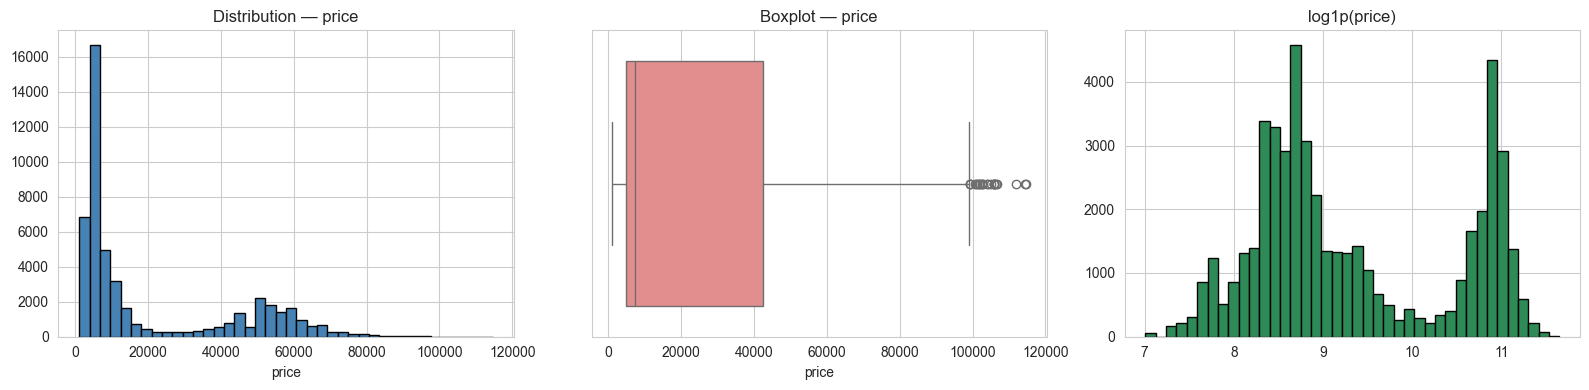

Skewness : 1.068
Kurtosis : -0.371
count     50000.00
mean      20827.47
std       22658.67
min        1105.00
25%        4784.00
50%        7424.00
75%       42521.00
max      114705.00
Name: price, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df['price'].dropna(), bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution — price')
axes[0].set_xlabel('price')
sns.boxplot(x=df['price'].dropna(), ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot — price')
# Log scale (skewed targets)
axes[2].hist(np.log1p(df['price'].dropna()), bins=40, color='seagreen', edgecolor='black')
axes[2].set_title('log1p(price)')
plt.tight_layout(); plt.show()
print('Skewness :', round(df['price'].skew(), 3))
print('Kurtosis :', round(df['price'].kurtosis(), 3))
print(df['price'].describe().round(2))

## 5. Univariate Analysis — Numeric Features

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'price' in numeric_cols:
    numeric_cols.remove('price')
print(f'Numeric features ({len(numeric_cols)}):')
print(numeric_cols[:30])

Numeric features (2):
['duration', 'days_left']


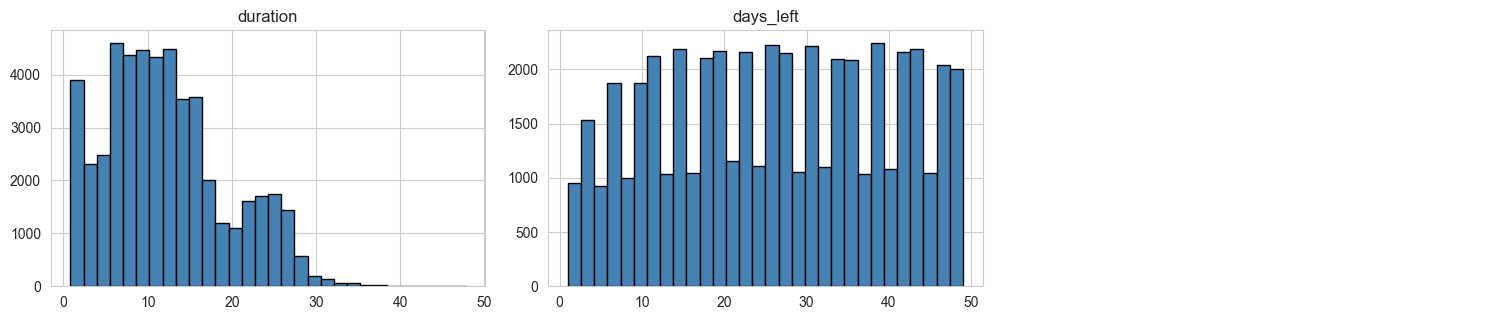

In [9]:
import math
n_show = min(len(numeric_cols), 12)
ncols = 3
nrows = math.ceil(n_show / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.3*nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols[:n_show]):
    df[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

## 6. Bivariate Analysis — Features vs Target

In [10]:
corrs_all = df[numeric_cols + ['price']].corr()['price'].abs().sort_values(ascending=False)
top_features = [c for c in corrs_all.index if c != 'price'][:6]
print('Top features by |correlation| with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation| with target:
duration     0.212
days_left    0.089
Name: price, dtype: float64


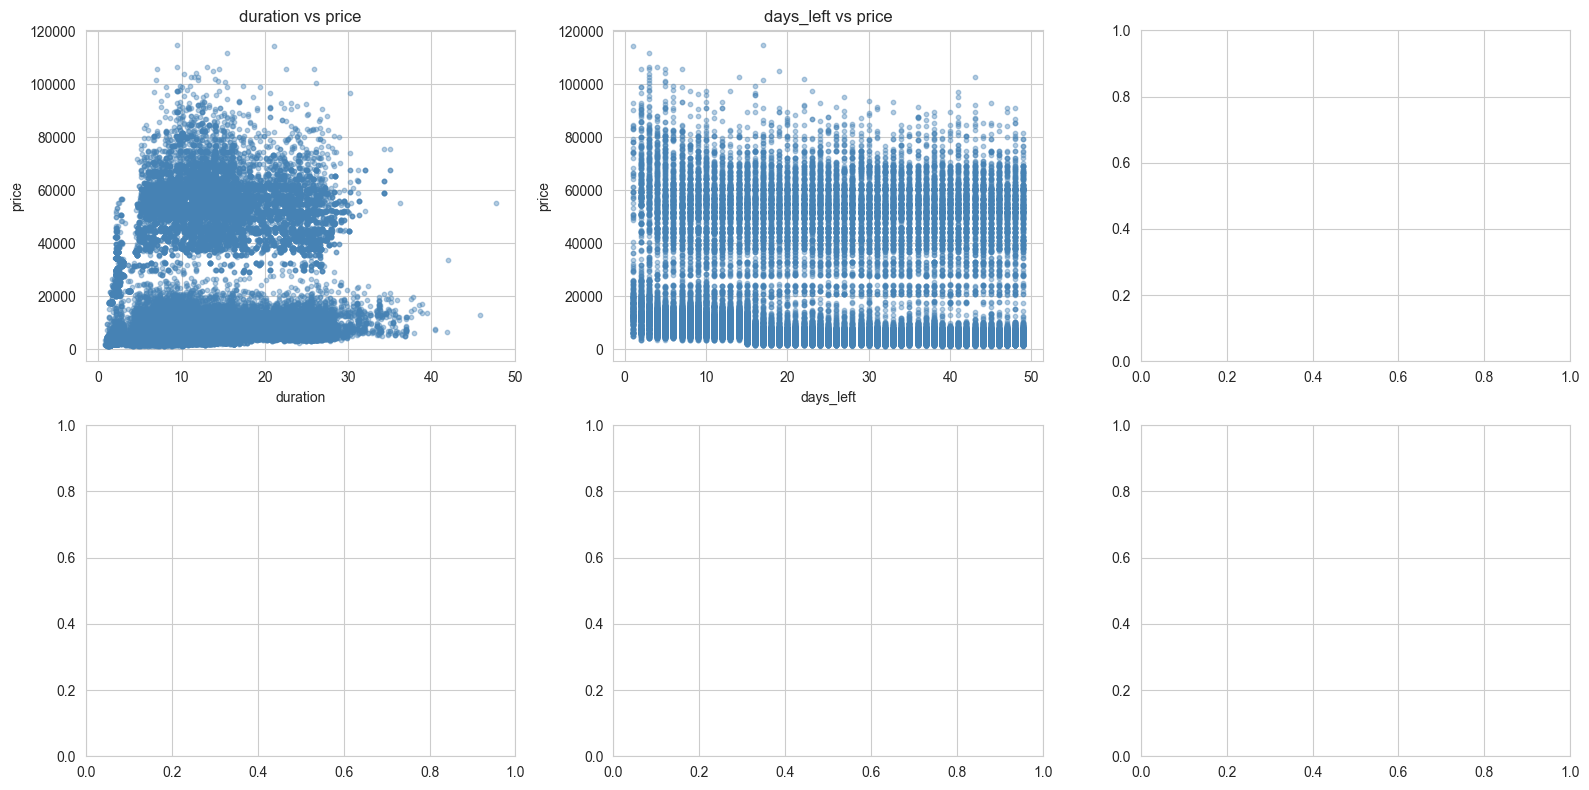

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(top_features[:6]):
    axes[i].scatter(df[col], df['price'], alpha=0.4, s=10, color='steelblue')
    axes[i].set_xlabel(col); axes[i].set_ylabel('price')
    axes[i].set_title(f'{col} vs price')
plt.tight_layout(); plt.show()

## 7. Correlation Analysis

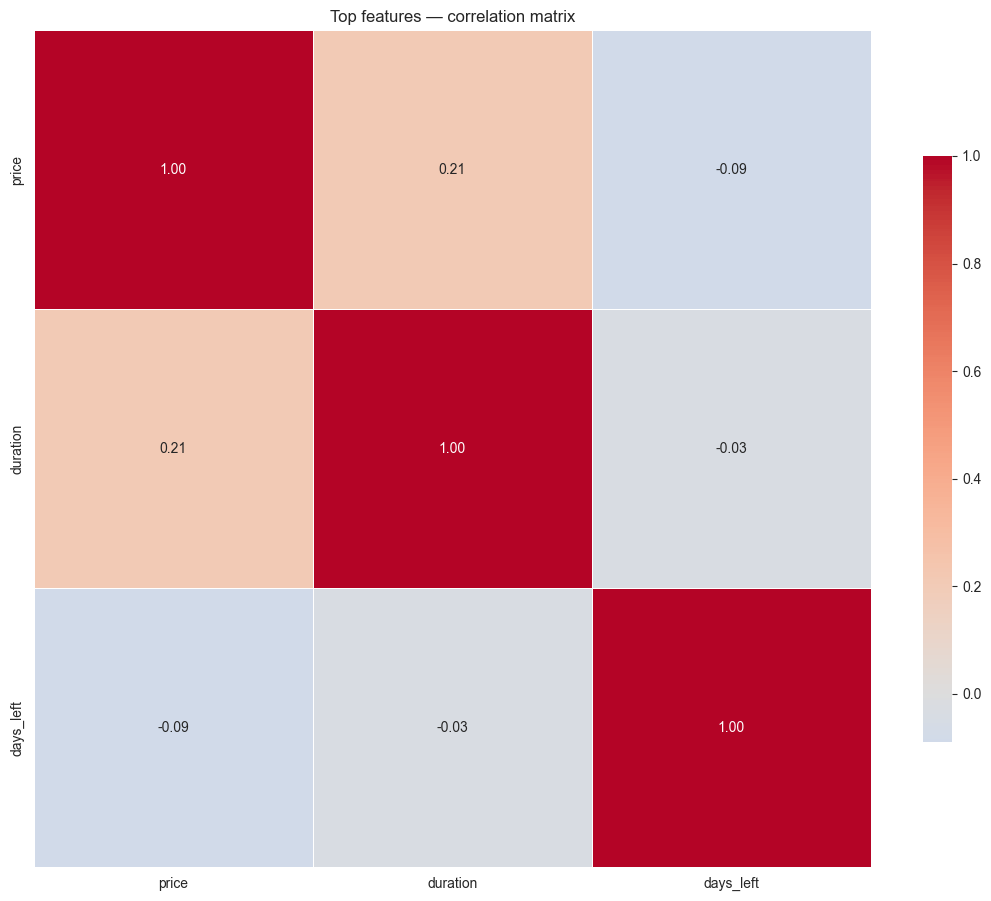

In [12]:
top_numeric = corrs_all.head(15).index.tolist()
if 'price' not in top_numeric:
    top_numeric.append('price')
corr_matrix = df[top_numeric].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix'); plt.tight_layout(); plt.show()

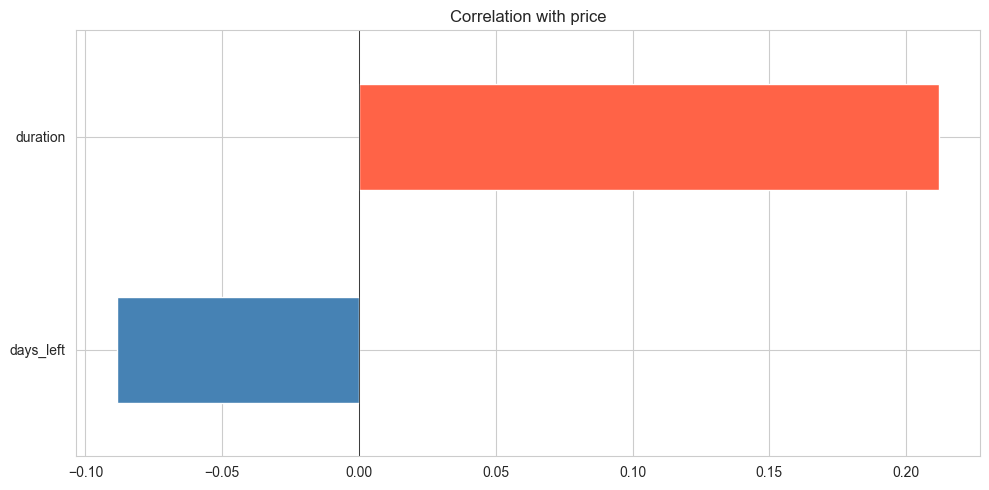

In [13]:
target_corr = df[numeric_cols + ['price']].corr()['price'].drop('price').sort_values()
plt.figure(figsize=(10, max(5, len(target_corr)*0.25)))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.title('Correlation with price')
plt.axvline(0, color='black', linewidth=0.5); plt.tight_layout(); plt.show()

## 8. Domain Deep-Dive — Class, Airline, Stops

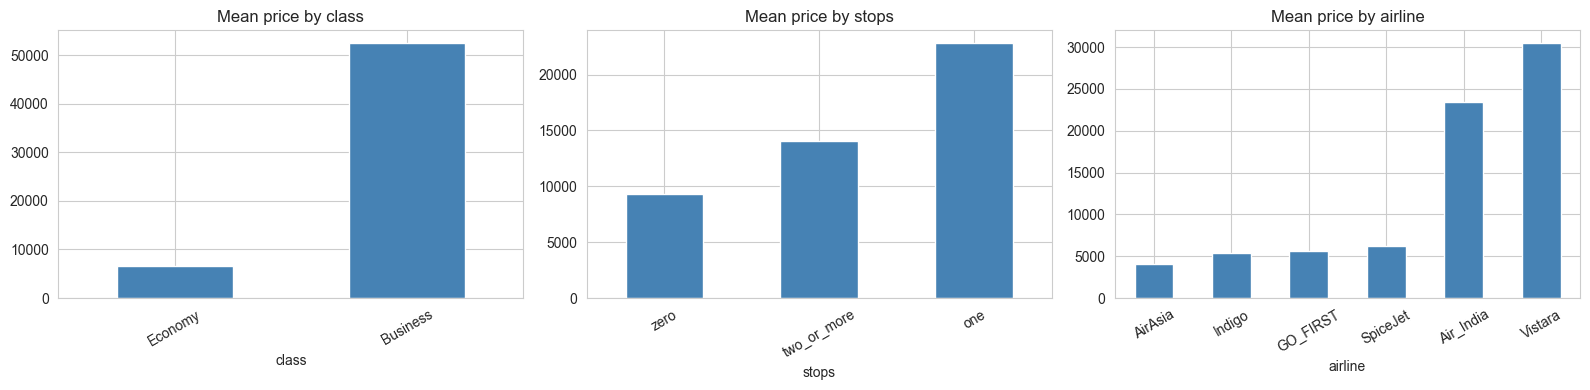

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['class', 'stops', 'airline']):
    if col in df.columns:
        df.groupby(col)['price'].mean().sort_values().plot(kind='bar', ax=ax, color='steelblue')
        ax.set_title(f'Mean price by {col}'); ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

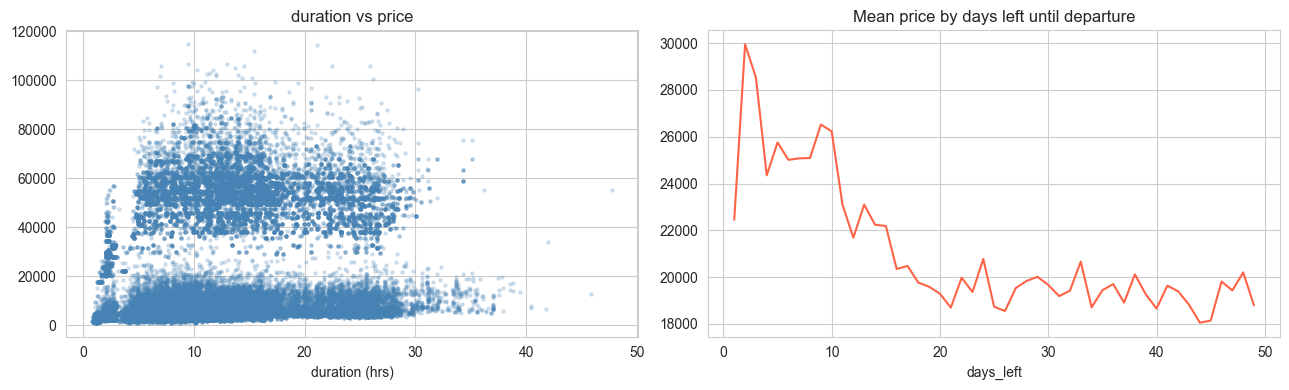

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
if 'duration' in df.columns:
    axes[0].scatter(df['duration'], df['price'], alpha=0.2, s=5, color='steelblue')
    axes[0].set_title('duration vs price'); axes[0].set_xlabel('duration (hrs)')
if 'days_left' in df.columns:
    df.groupby('days_left')['price'].mean().plot(ax=axes[1], color='tomato')
    axes[1].set_title('Mean price by days left until departure')
plt.tight_layout(); plt.show()

## 9. Pair Plot — Top Features

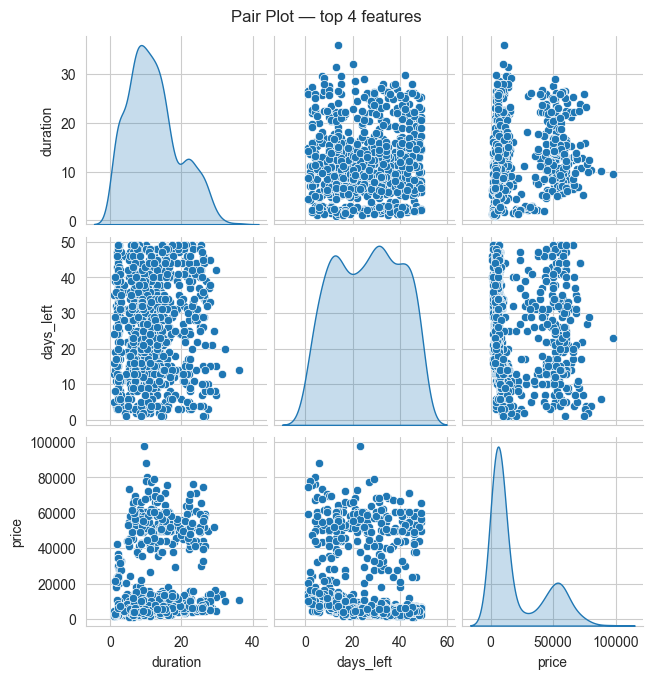

In [16]:
sample = df.sample(min(800, len(df)), random_state=42)
sns.pairplot(sample[top_features[:4] + ['price']].dropna(), diag_kind='kde', height=2.2)
plt.suptitle('Pair Plot — top 4 features', y=1.02); plt.show()

## 10. Summary of Key Findings

In [17]:
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Target mean', 'Target median',
               'Target stddev', 'Target min', 'Target max', 'Target skewness',
               'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df), df.shape[1] - 1,
        round(df['price'].mean(), 2),
        round(df['price'].median(), 2),
        round(df['price'].std(), 2),
        round(df['price'].min(), 2),
        round(df['price'].max(), 2),
        round(df['price'].skew(), 3),
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,50000
1,Total features,9
2,Target mean,20827.47
3,Target median,7424.0
4,Target stddev,22658.67
5,Target min,1105
6,Target max,114705
7,Target skewness,1.068
8,Top correlated feature,duration
9,Top correlation value,0.212
